# Deep Image Prior

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from tqdm import tqdm

from dip import *

np.random.seed(0)

In [2]:
def generate_sampling_mask(size, sample_fraction=0.5, sampling_scheme='variable-density', sampling_dim_option='1D'):

    num_rows, num_cols = size
    mask = np.zeros((num_rows, num_cols))
    
    if sampling_dim_option == '1D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':

            center_fraction = 0.08
            assert sample_fraction > center_fraction

            num_center_cols = int(center_fraction * num_cols)
            center_cols_range = (num_cols // 2 - num_center_cols // 2,  num_cols // 2 + num_center_cols // 2)
            mask[:, center_cols_range[0] : center_cols_range[1]] = 1
            
            pmf = np.ones(num_cols)
            pmf[center_cols_range[0] : center_cols_range[1]] = 0
            pmf = pmf / pmf.sum()
            
            sample_fraction = sample_fraction - center_fraction

        num_sample_lines = int(sample_fraction * num_cols)
        sampled_lines = np.random.choice(np.arange(num_cols), size=num_sample_lines, replace=False, p=pmf)        
        mask[:, sampled_lines] = 1

    elif sampling_dim_option == '2D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':
            # TODO
            pass
        
        grid_i, grid_j = np.meshgrid(np.arange(num_rows), np.arange(num_cols), indexing='ij')
        kspace_coords = np.stack((grid_i.flatten(), grid_j.flatten()), axis=1)
        num_samples = int(sample_fraction * (num_rows * num_cols))
        idxs = np.random.choice(np.arange(num_rows * num_cols), size=num_samples, replace=False, p=pmf)
        sampled_coords = kspace_coords[idxs]
        mask[sampled_coords[:, 0], sampled_coords[:, 1]] = 1

    return torch.tensor(mask.astype(bool))


/var/folders/z2/9mvdhdzs759cl3k47r3lm3m00000gn/T/ipykernel_1871/2603601403.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axs[2].imshow(np.abs(image_zf), cmap='gray')


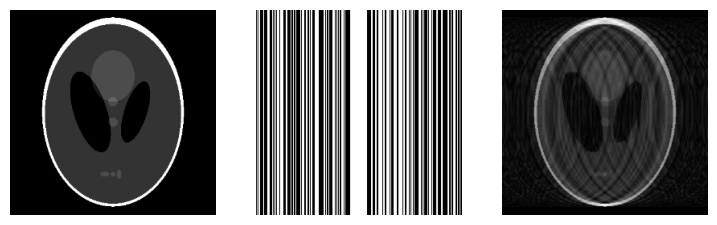

In [ ]:
image_size = (256, 256)

# Create Shepp-Logan phantom image and simulate k-sapce measurement
image_gt = shepp_logan_phantom().astype(np.float32)
image_gt = torch.tensor(resize(image_gt, image_size, anti_aliasing=True))

mask = generate_sampling_mask(image_gt.shape, sample_fraction=0.5)
kspace = fft2c(image_gt) * mask.to(torch.float32)
image_zf = ifft2c(kspace)  # Zero-filled reconstruction baseline

kspace = kspace.unsqueeze(0)
mask = mask.unsqueeze(0)

# Display
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs[0].imshow(image_gt, cmap='gray')
axs[1].imshow(mask.squeeze(), cmap='gray')
axs[2].imshow(image_zf.abs(), cmap='gray')
[ax.axis('off') for ax in axs]
plt.show()

100%|██████████| 5000/5000 [28:32<00:00,  2.92it/s]    


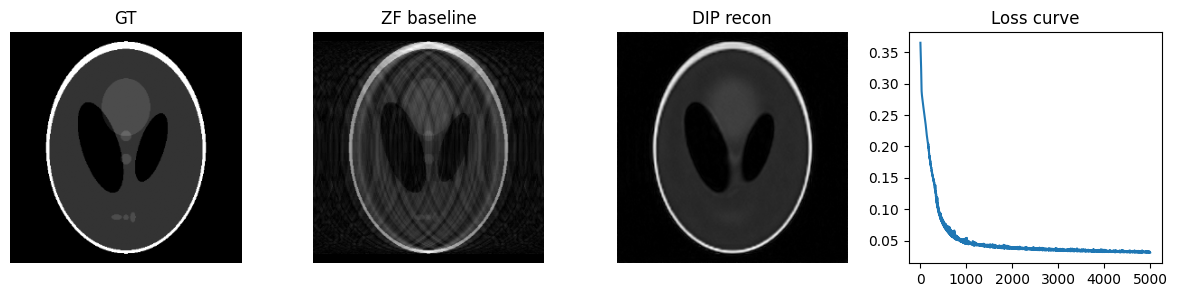

In [8]:
net_num_filters = 8
net_depth = 5
lr = 1e-4
num_iters = 5000

net = UNet(num_filters=net_num_filters, depth=net_depth)
opt = torch.optim.Adam(net.parameters(), lr=lr)
z = torch.randn(1, 2, image_size[0], image_size[1])

loss_curve = []
for it in tqdm(range(num_iters)):
    opt.zero_grad(set_to_none=True)
    image_estim = net(z)
    image_estim = image_estim[:,0] + 1j*image_estim[:,1]
    kspace_estim = fft2c(image_estim) * mask # Explicit regularization: image always lies in the range of the net
    loss = torch.linalg.norm((kspace_estim - kspace).flatten(), ord=2) / torch.prod(torch.tensor(kspace.shape))
    loss.backward()
    opt.step()
    loss_curve.append(loss.item())
image_estim = image_estim.detach()

# Display
fig, axs = plt.subplots(1, 4, figsize=(15, 3))
axs[0].imshow(image_gt.abs().cpu().squeeze(), cmap='gray'); axs[0].set_title("GT")
axs[1].imshow(image_zf.abs().cpu().squeeze(), cmap='gray'); axs[1].set_title("ZF baseline")
axs[2].imshow(image_estim.abs().cpu().squeeze(), cmap='gray'); axs[2].set_title("DIP recon")
axs[3].plot(loss_curve); axs[3].set_title("Loss curve")
[axs[i].axis('off') for i in range(3)]
plt.show()